<br/>

<div align="center">
<span style="font-size: 2.5em;">Halo Model Comparison</span>
<br/>
<span style="font-size: 1.2em; color: gray;">Assessing neural network posterior accuracy, precision, and calibration across different dark matter halo models</span>
</div>

## Overview

This notebook evaluates neural network-based posteriors trained on different dark matter halo models. We investigate:

- **Coverage Tests**: Verify that inferred credible regions contain true parameters at the nominal confidence level
- **Accuracy & Precision**: Measure how close MAP estimates are to true parameters (Euclidean, Mahalanobis distance) and posterior sharpness (volume)
- **Halo Dependence**: Test whether inference results degrade when using a misspecified halo model


## Methodology

For each spectrum generated from a fixed halo model (e.g., `x1`), we compute posteriors using neural networks trained on different halo assumptions. This tests:

1. **Calibration (Coverage)**: Do credible regions contain the true parameters at the expected frequency?
2. **Accuracy**: How close is the MAP estimate to the true parameters?
3. **Precision (Relative Volume)**: Is the posterior sharper or broader than the reference model's posterior?

## Extreme Halo Models for Concept Demonstration

**Why x1 and x2?** The primary halo models used in realistic dark matter analyses (SHM, SHMpp, LMC) are all very similar and produce nearly indistinguishable posteriors. To demonstrate the *conceptual* differences between halo-dependent inference, we use **extreme halo models** (x1, x2) that represent ±5σ variations in the Standard Halo Model parameters. 

- x1: v + 5σ (higher velocities)
- x2: v - 5σ (lower velocites)

This extreme separation clearly shows:
- How different halo assumptions affect the inferred parameter space
- Systematic biases when using misspecified models

**Important**: These extreme models are not realistic but serve as conceptual test cases. In real analyses, halo model variations typically produce much smaller differences in posteriors.

In [ ]:
# =============================
# IMPORTS AND PATH SETTINGS
# =============================

import os
desired_root_name = "xenon-sbi" 
while os.path.basename(os.getcwd()) != desired_root_name:
    os.chdir(os.path.abspath(os.path.join(os.getcwd(), "..")))

import torch
import numpy as np
from configs.config import MCConfig, PARAM_RANGES, load_halo_models
from utils.posteriors import posterior_halo_comparison
from performances.metrics import (
    coverage_halo_comparison,
    evaluate_posterior_quality_halo,
    compare_metric_histograms,
)

In [2]:
# ===========================================
# PARAMETERS TO DEFINE THE DATA AND MODEL 
# ===========================================

modelname = "ntothighest"   # modelname = "full"            
datatag   = "low"           # datatag = "mid" or "high"      
n_train   = 300_000
halos = ["x1", "x2"]        # halos = ["shm", "x1", "x2"]
halo_choice = "x1" 

mc_cfg = MCConfig()  
bins = mc_cfg.bins     
top_k     = 10             

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# =============================
# LOAD MODELS
# =============================

models, labels = load_halo_models(
    halos=halos,
    modelname=modelname,
    n_train=n_train,
    datatag=datatag,
    bins=bins,
    top_k=top_k,
    device=device,
)

Loading model from models/wimpy\x1\ntothighest_n300000_low_x1.pt
Loading model from models/wimpy\x2\ntothighest_n300000_low_x2.pt
Loading combined model from models/wimpy\combined\x1_x2\ntothighest_n300000_low_x1_x2.pt


## 1. Qualitative Posterior Comparison

Visualize posteriors from different halo models for a single example spectrum. This provides intuition for how halo assumptions affect the inferred parameter space.

In [ ]:
# ==========================================================
# Wrapper to run halo comparison
# ==========================================================

def run_halo_comparison(m, cp, halo_choice, models, labels, save_path=None):
    posterior_halo_comparison(
        models=models,
        labels=labels,
        mchi_true=m,
        cp_true=cp,
        halo_choice=halo_choice,
        logm_range=PARAM_RANGES[datatag]["logm_range"],
        logcp_range=PARAM_RANGES[datatag]["logcp_range"],
        save_path=save_path,
    )


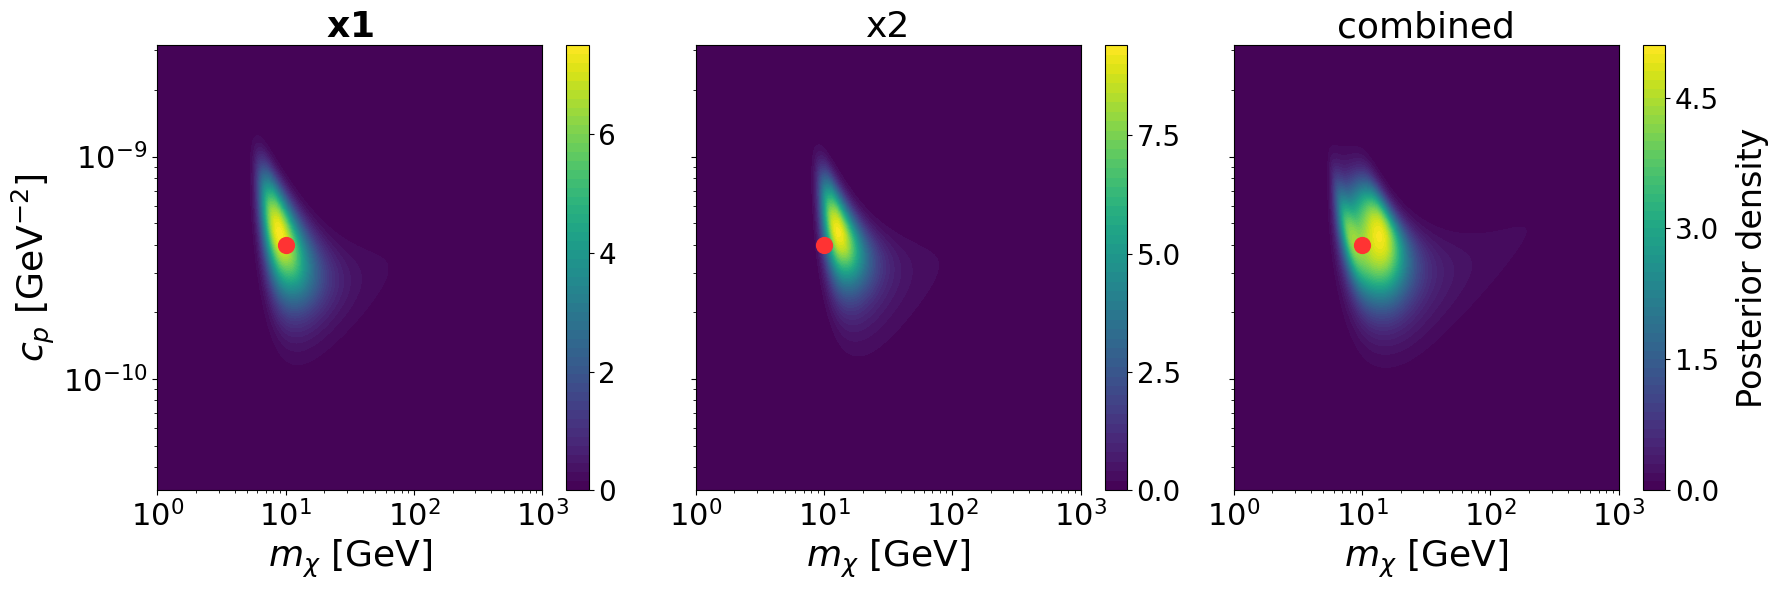

In [ ]:
run_halo_comparison(
    m=10.0,
    cp=10**(-9.4),
    halo_choice=halo_choice,
    models=models,
    labels=labels,
    #save_path=f"figures/...",
)

## 2. Coverage Analysis

### Full Parameter Space
**Expectation**: Coverage should be best for the correct halo model and degrade for misspecified models.

**Key Findings**:
- **Correct halo model**: Excellent coverage across all nominal levels 
- **Wrong halo model**: Severe undercoverage — posteriors are too narrow, missing true parameters frequently
- **Combined model**: Excellent coverage restored, behaving like a "safest" choice that marginalizes over halo uncertainty

Loading dataset from:
data/datasets/wimpy/x1/wimpy_n300000_low_x1.pt

Total test samples: 45107
Running coverage test for: x1
Running coverage test for: x2
Running coverage test for: combined


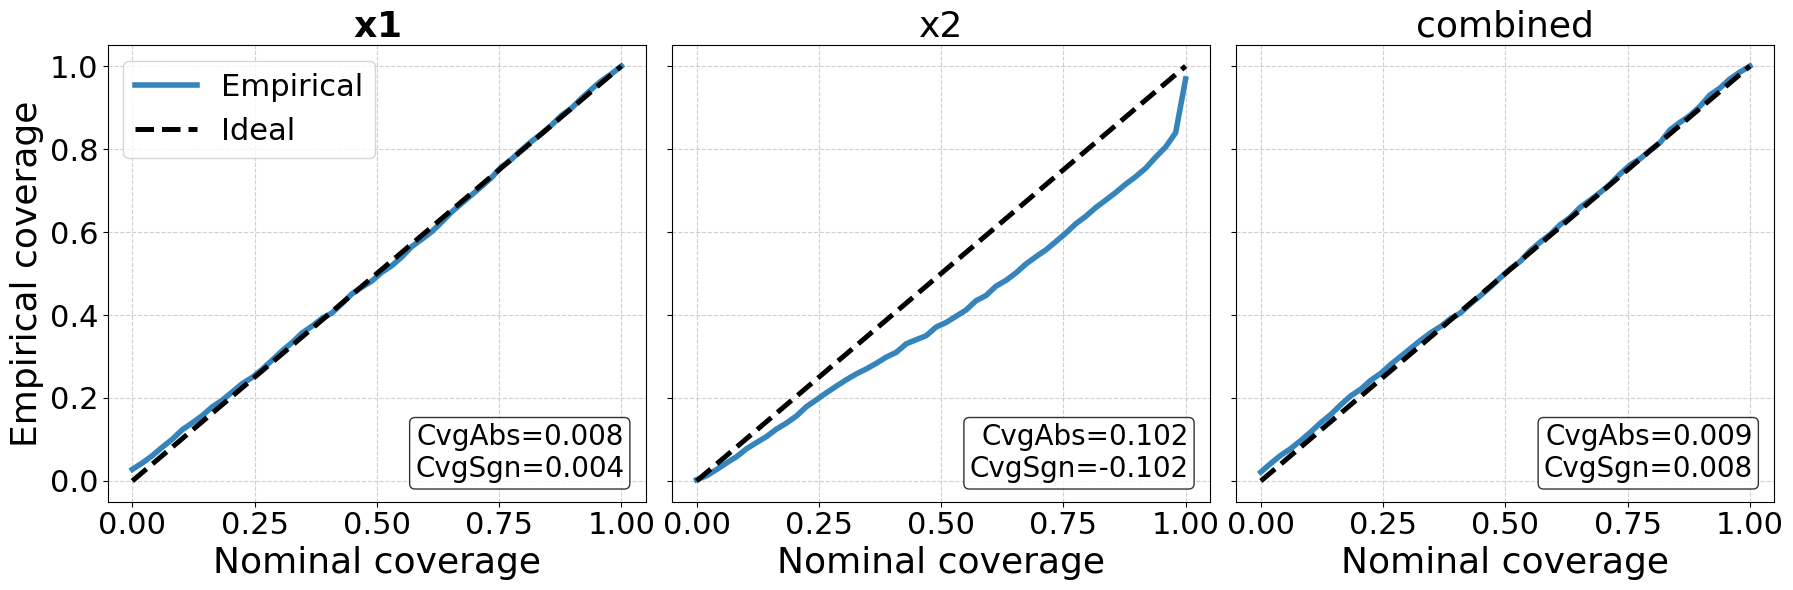

In [ ]:
# ==========================================================
# Coverage comparisons 
# ==========================================================

coverage_halo_comparison(
    models=models,
    labels=labels,
    halo_choice=halo_choice,
    datatag=datatag,
    n_train=n_train,
    logm_range=PARAM_RANGES[datatag]["logm_range"],
    logcp_range=PARAM_RANGES[datatag]["logcp_range"],
    device=device,
    levels=np.linspace(0, 1, 50),
    posteriorbins=50,
    n_samples=5000,
    #savepath=f"figures/...",
 )



### Focused Parameter Region
To make the halo distinction even more apparent, we focus on a parameter window with low masses where different halos produce significantly different physics. This increases sensitivity to model misspecification.

**Note**: Coverage alone does not reveal whether posteriors are unnecessarily broad (overconfident in phase space) or unreasonably narrow. We need complementary metrics.

Loading dataset from:
data/datasets/wimpy/x1/wimpy_n300000_low_x1.pt

Filtered test samples: 8724
Running coverage test for: x1
Running coverage test for: x2
Running coverage test for: combined


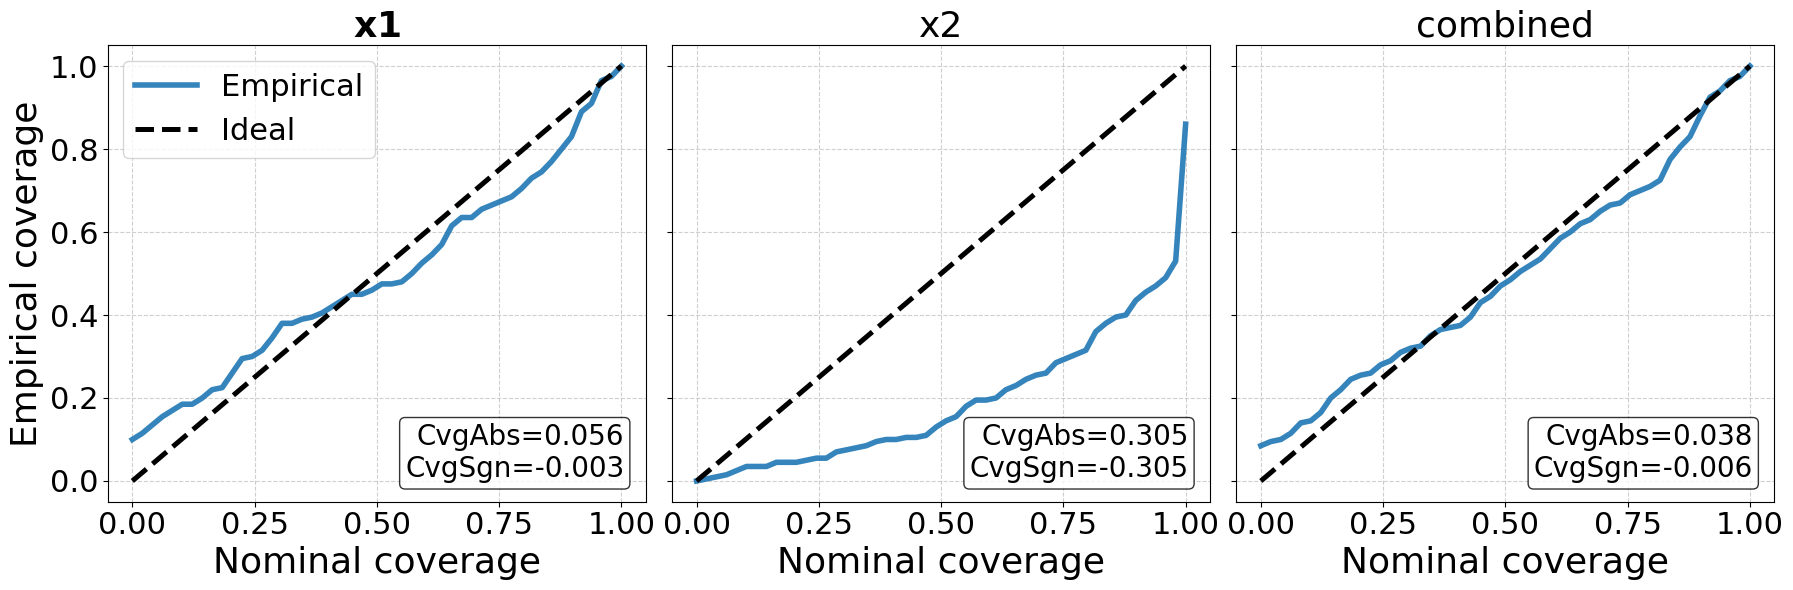

In [8]:
# ==========================================================
# Coverage comparisons in a smaller parameter space
# ==========================================================

coverage_halo_comparison(
    models=models,
    labels=labels,
    halo_choice=halo_choice,
    datatag=datatag,
    n_train=n_train,
    logm_range=PARAM_RANGES[datatag]["logm_range"],
    logcp_range=PARAM_RANGES[datatag]["logcp_range"],
    device=device,
    levels=np.linspace(0, 1, 50),
    posteriorbins=50,
    n_samples=200,
    logm_window=(np.log10(5), np.log10(30)),
    logcp_window=(-10, -8.5),
    savepath=None,
 )

**Key Findings in the Focused Window**:
- **Correct halo model**: Coverage remains fairly good
- **Wrong halo model**: Coverage is terrible — severe undercoverage with posteriors far too narrow to contain true parameters
- **Combined model**: Coverage degrades slightly compared to the correct model, but is **still miles better than the misspecified case**, demonstrating its robustness across halo assumptions

The windowed analysis confirms what we observed in the full parameter space: halo misspecification causes dramatic undercoverage when posteriors are overly sharp. The combined model acts as a conservative fallback, sacrificing some sharpness for broad coverage protection.

## 3. Accuracy & Precision Metrics

Complement coverage tests with direct measurements of posterior accuracy and sharpness. The evaluation excludes zero-event spectra to avoid misleading distances in exclusion regions.

### Metric Definitions (short)

- **Euclidean distance**: $d_{\mathrm{Eucl}} = \|\theta_{\mathrm{MAP}}-\theta_{\mathrm{true}}\|$ (location accuracy).
- **Mahalanobis distance**: $d_{\mathrm{Maha}} = \sqrt{(\theta_{\mathrm{MAP}}-\mu)^T\Sigma^{-1}(\theta_{\mathrm{MAP}}-\mu)}$ (accuracy relative to uncertainty; $\sim 1$ if calibrated).
- **Posterior volume**: $V=\sqrt{\det(\Sigma)}$; we report **volume ratios** relative to the true-halo model ($>1$ broader, $<1$ narrower).

### 3.1 Full Parameter Space (no window)

Metrics computed across the full parameter space (no windowing).

In [6]:
performances = evaluate_posterior_quality_halo(
    models,
    labels,
    halo_choice=halo_choice,
    datatag=datatag,
    n_train=n_train,
    device=device,
    posteriorbins=50, 
    n_samples=5000,
)

Loading dataset from:
data/datasets/wimpy/x1/wimpy_n300000_low_x1.pt

Non-zero test samples: 21213
Evaluating model: x1
Evaluating model: x2
Evaluating model: combined


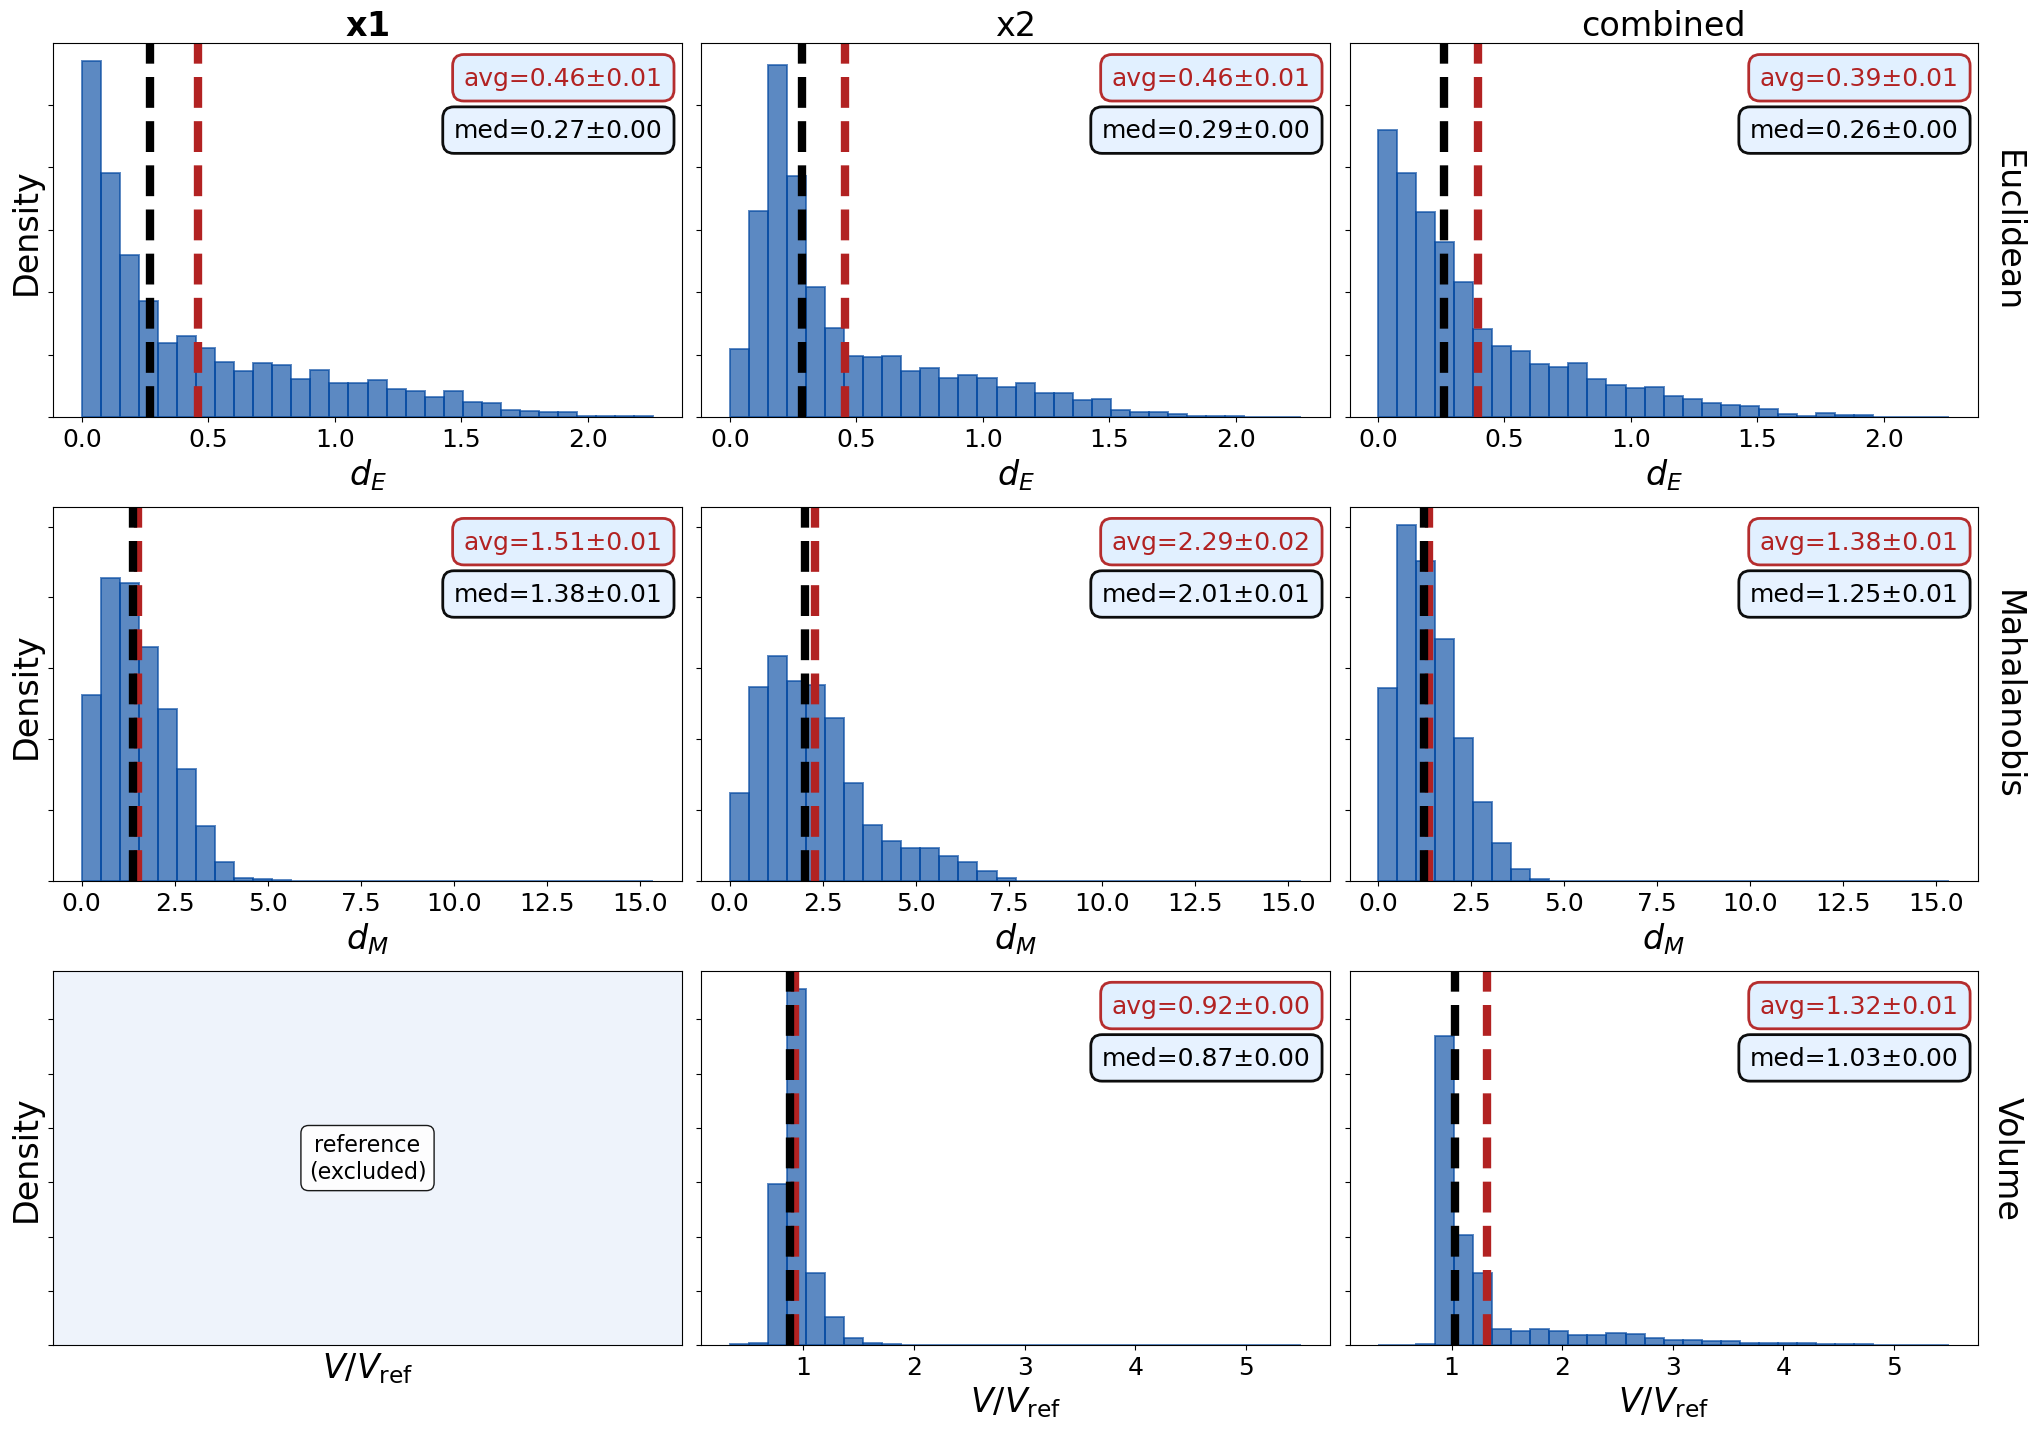

In [ ]:
compare_metric_histograms(
    performances,
    bins=30,
    reference_label="x1",
    #savepath=f"figures/...",
)